In [12]:
import numpy as np
import matplotlib.pyplot as plt
plt.gray()

data = np.load('raya_circulo.npz')
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

<Figure size 640x480 with 0 Axes>

In [13]:
X_train.shape

(20, 30, 30, 1)

In [14]:
y_train

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1.])

In [15]:
#Ver el valor maximo porsi necesita escalado
np.max(X_train) #Lo está

np.float64(1.0)

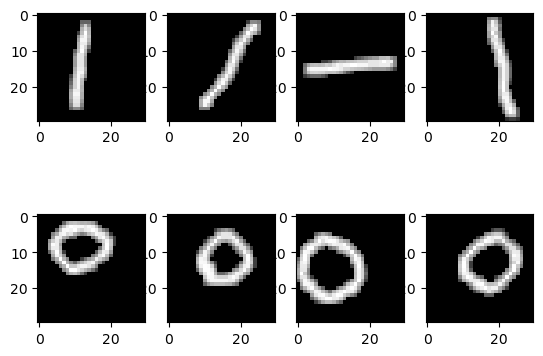

In [16]:
for i in range(0, 4):
    plt.subplot(2, 4, i+1)
    plt.imshow(X_train[i])
    plt.subplot(2, 4, 4+i+1)
    plt.imshow(X_train[10+i])

In [17]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, AvgPool2D
from tensorflow.keras.layers import Dense, Flatten

red = Sequential()

In [18]:
red.add(Conv2D(
    8, #Numero de kernels
    kernel_size=(5,5), #tamaño de kernels
    input_shape = (30,30,1),
    activation = None
    ))

c:\Users\David\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
red.add(Conv2D(
    12, #Numero de kernels
    kernel_size=(3,3), #tamaño de kernels
    activation = None
    ))

red.add(AvgPool2D(pool_size=(2, 2)))

red.add(Conv2D(
    16, #Numero de kernels
    kernel_size=(3,3), #tamaño de kernels
    activation = None
    ))

red.add(MaxPool2D(pool_size=(2, 2)))

In [20]:
red.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 12)     │           876 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 12, 12, 12)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 16)     │         1,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,828 (11.05 KB)

 Trainable params: 2,828 (11.05 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
red.add(Flatten())
red.add(Dense(800, activation="relu"))
red.add(Dense(1, activation="sigmoid"))

In [22]:
red.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 12)     │           876 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 12, 12, 12)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 16)     │         1,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 800)            │       320,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324,429 (1.24 MB)

 Trainable params: 324,429 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
red.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["binary_accuracy"]
)

In [25]:
h = red.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=1,
    shuffle=True)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - binary_accuracy: 0.4000 - loss: 0.8032 - val_binary_accuracy: 0.8333 - val_loss: 0.5998
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.8000 - loss: 0.5899 - val_binary_accuracy: 0.8333 - val_loss: 0.5356
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.8500 - loss: 0.4310 - val_binary_accuracy: 1.0000 - val_loss: 0.4033
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.9500 - loss: 0.2714 - val_binary_accuracy: 0.8333 - val_loss: 0.2953
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.9500 - loss: 0.1394 - val_binary_accuracy: 0.8333 - val_loss: 0.2208
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.9000 - loss: 0.0961 - val_binary_accuracy: 1.0000 - val_loss: 0.2223
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.9500 - loss: 0.0777 - val_binary_accuracy: 1.0000 - val_loss: 0.2089
Epoch 8/30
20/20 ━━

In [26]:
h.history.keys()

dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])

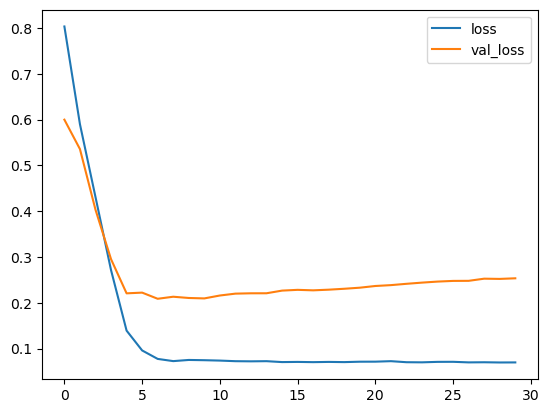

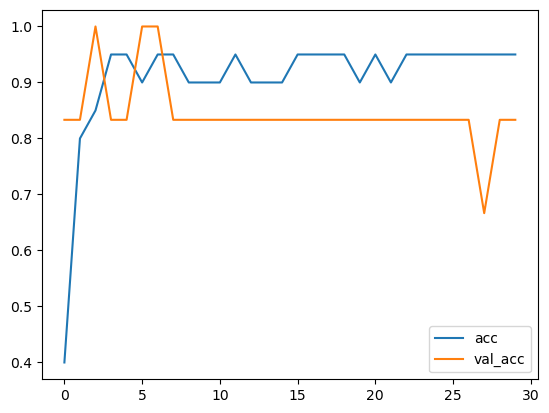

In [27]:
import matplotlib.pyplot as plt
plt.plot(h.history['loss'], label='loss')
plt.plot(h.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

plt.plot(h.history['binary_accuracy'], label='acc')
plt.plot(h.history['val_binary_accuracy'], label='val_acc')
plt.legend()
plt.show()
